# NLP Feature Extraction

Extract linguistic features from movie subtitles for the success prediction model.

**Features extracted:** basic text statistics, lexical diversity, VADER sentiment, punctuation features, sentiment variance, readability, TextBlob polarity/subjectivity, and TF-IDF vectors.

All extraction logic lives in `src/nlp_features.py`; this notebook calls those functions and visualises the results.

**Input:** Subtitle text files from `../data/raw/subtitles/`
**Output:** `../data/processed/nlp_features.csv` + TF-IDF matrix

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse
import pickle
import re
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from src.nlp_features import (
    clean_subtitle_text, clean_subtitle_text_for_sentiment,
    extract_basic_text_stats, extract_lexical_diversity,
    extract_sentiment_features, extract_punctuation_features,
    extract_sentiment_variance, extract_readability, extract_textblob_features,
    process_subtitle_batch, create_tfidf_vectorizer, get_top_tfidf_terms,
)

plt.style.use('default')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

DATA_DIR = Path('../data')
PROCESSED_DIR = DATA_DIR / 'processed'
RAW_DIR = DATA_DIR / 'raw'
SUBTITLES_DIR = RAW_DIR / 'subtitles'
FIGURES_DIR = Path('figures')
FIGURES_DIR.mkdir(exist_ok=True)

## 1. Subtitle Loading

Load the main dataset, scan the subtitle directory, and match files to movie IDs.

About 58% of movies have subtitles; this subset will be used for NLP feature extraction and modeling.

In [2]:
df = pd.read_csv(PROCESSED_DIR / 'final_movie_list.csv')
print(f"Main dataset: {len(df):,} movies")

subtitle_files = list(SUBTITLES_DIR.glob('*.txt'))
print(f"Subtitle files found: {len(subtitle_files):,}")

subtitle_ids = set()
subtitle_file_map = {}
for fp in subtitle_files:
    try:
        mid = int(fp.stem)
        subtitle_ids.add(mid)
        subtitle_file_map[mid] = fp
    except ValueError:
        continue

print(f"Valid subtitle movie IDs: {len(subtitle_ids):,}")

df['has_subtitles'] = df['id'].isin(subtitle_ids)
movies_with_subs = df[df['has_subtitles']]
print(f"\nMovies with subtitles: {len(movies_with_subs):,} ({len(movies_with_subs)/len(df)*100:.1f}%)")
print(f"Movies without subtitles: {len(df) - len(movies_with_subs):,} ({(len(df) - len(movies_with_subs))/len(df)*100:.1f}%)")

sample_ids = list(subtitle_ids)[:3]
print("\nSample subtitle content:")
for mid in sample_ids:
    title = df.loc[df['id'] == mid, 'title'].iloc[0]
    with open(subtitle_file_map[mid], 'r', encoding='utf-8', errors='ignore') as f:
        snippet = f.read()[:200]
    print(f"\n--- {title} (ID: {mid}) ---")
    print(repr(snippet + '...'))

Main dataset: 12,722 movies
Subtitle files found: 7,423
Valid subtitle movie IDs: 7,423

Movies with subtitles: 7,423 (58.3%)
Movies without subtitles: 5,299 (41.7%)

Sample subtitle content:

--- Four Rooms (ID: 5) ---
"We used to have 50 on staff here. 50.\nI'm the only one left.\nAll comes down to one schmuck.\nMe, the night shift bellhop.\nWhat the hell is that? A bellhop?\nHuh? What is he?\nYou know where the name\ncome..."

--- Judgment Night (ID: 6) ---
"♪♪ Traveling ♪♪\n♪♪ At the speed ♪♪\n♪♪ Of love ♪♪\n♪♪ Do-do-do-do\ndo-do-do-do ♪♪\n♪♪ Do-do-do-do\ndo-do-do-do ♪♪\n♪♪ Do-do-do-do\ndo-do-do-do ♪♪\n♪♪ Do-do-do-do\ndo-do-do-do ♪♪\n♪♪ Hey yo kids ♪♪\n♪♪ What's up?..."

--- Finding Nemo (ID: 12) ---
"Yes, Marlin.\nI see it. It's beautiful.\nSo, Coral, when you said\nyou wanted an ocean view,\nyou didn't think you were going\nto get the whole ocean, did you?\nOh, yeah!\nA fish can breathe out here.\nDid yo..."


~58% of movies have subtitle files. The remaining movies will not have NLP features; we use an inner join at modeling time.

## 2. Text Cleaning Demo

Two cleaning modes from `src/nlp_features.py`: strict (for stats/TF-IDF) and lenient (for sentiment, preserves punctuation).

In [3]:
sample_text = (
    "1\n00:00:05,123 --> 00:00:10,456\nHello! How are you?\n\n"
    "2\n00:00:10,456 --> 00:00:15,789\nI'm fine, thank you!\n\n"
    "3\n00:00:15,789 --> 00:00:20,012\n<i>Really?</i> [LAUGHTER] (crowd cheers)\n"
)

print("Original:")
print(repr(sample_text))
print("\nStrict cleaning (for feature extraction):")
print(repr(clean_subtitle_text(sample_text)))
print("\nSentiment cleaning (keeps more punctuation):")
print(repr(clean_subtitle_text_for_sentiment(sample_text)))

Original:
"1\n00:00:05,123 --> 00:00:10,456\nHello! How are you?\n\n2\n00:00:10,456 --> 00:00:15,789\nI'm fine, thank you!\n\n3\n00:00:15,789 --> 00:00:20,012\n<i>Really?</i> [LAUGHTER] (crowd cheers)\n"

Strict cleaning (for feature extraction):
" Hello! How are you?  I'm fine, thank you!  Really?"

Sentiment cleaning (keeps more punctuation):
"1 Hello! How are you? 2 I'm fine, thank you! 3 Really? (crowd cheers)"


Strict cleaning removes timestamps, HTML tags, brackets, parenthetical stage directions, and non-English characters. Sentiment cleaning is more permissive to retain emotional cues.

## 3. Full Feature Extraction

Use `process_subtitle_batch()` to extract **all** NLP features in one pass: basic stats, lexical diversity, VADER sentiment, punctuation ratios, sentiment variance, readability, and TextBlob. This processes ~7,400 files and takes 5–10 minutes.

In [4]:
movie_ids = sorted(movies_with_subs['id'].tolist())
print(f"Processing {len(movie_ids):,} subtitle files...")

nlp_df = process_subtitle_batch(movie_ids, SUBTITLES_DIR, progress_every=500)
print(f"\nResult shape: {nlp_df.shape}")
print(f"Columns: {list(nlp_df.columns)}")
nlp_df.head()

Processing 7,423 subtitle files...
  Processed 500 files...
  Processed 1,000 files...
  Processed 1,500 files...
  Processed 2,000 files...
  Processed 2,500 files...
  Processed 3,000 files...
  Processed 3,500 files...
  Processed 4,000 files...
  Processed 4,500 files...
  Processed 5,000 files...
  Processed 5,500 files...
  Processed 6,000 files...
  Processed 6,500 files...
  Processed 7,000 files...
Done: 7,423 processed, 0 errors

Result shape: (7423, 22)
Columns: ['id', 'raw_text_length', 'cleaned_text_length', 'word_count', 'sentence_count', 'avg_sentence_length', 'char_count', 'type_token_ratio', 'hapax_legomena_ratio', 'unique_words', 'sentiment_compound', 'sentiment_pos', 'sentiment_neg', 'sentiment_neu', 'emotional_intensity', 'exclamation_ratio', 'question_ratio', 'sentiment_compound_std', 'avg_word_length', 'sentence_length_std', 'textblob_polarity', 'textblob_subjectivity']


,id,raw_text_length,cleaned_text_length,word_count,sentence_count,avg_sentence_length,char_count,type_token_ratio,hapax_legomena_ratio,unique_words,...,sentiment_neg,sentiment_neu,emotional_intensity,exclamation_ratio,question_ratio,sentiment_compound_std,avg_word_length,sentence_length_std,textblob_polarity,textblob_subjectivity
0,5,47633,47417,9031,1561,5.785394,47417,0.151094,0.073158,1423,...,0.149,0.715,0.285,0.136451,0.167201,0.301074,4.247149,5.279136,0.016980,0.564327
1,6,50508,49792,9462,1831,5.167668,49792,0.125251,0.057816,1250,...,0.158,0.713,0.286,0.131622,0.188968,0.280638,4.227436,12.150314,0.076071,0.530130
2,12,48197,48110,9493,2306,4.116652,48110,0.137409,0.070219,1315,...,0.071,0.740,0.260,0.153079,0.148742,0.220835,4.066259,3.245144,0.146497,0.524009
3,13,61625,60549,11642,1639,7.103112,60549,0.136759,0.070723,1634,...,0.092,0.755,0.245,0.177547,0.125076,0.290567,4.197732,6.140608,0.131146,0.525132
4,14,42497,42396,8179,1433,5.707606,42396,0.174819,0.099930,1494,...,0.130,0.692,0.309,0.105373,0.182135,0.298567,4.181929,4.813308,0.085741,0.549096


All NLP features for every subtitle are now in `nlp_df`. The following sections visualise individual feature groups.

## 4. Basic Text Statistics

Distributions of word count, sentence count, average sentence length, and character count.

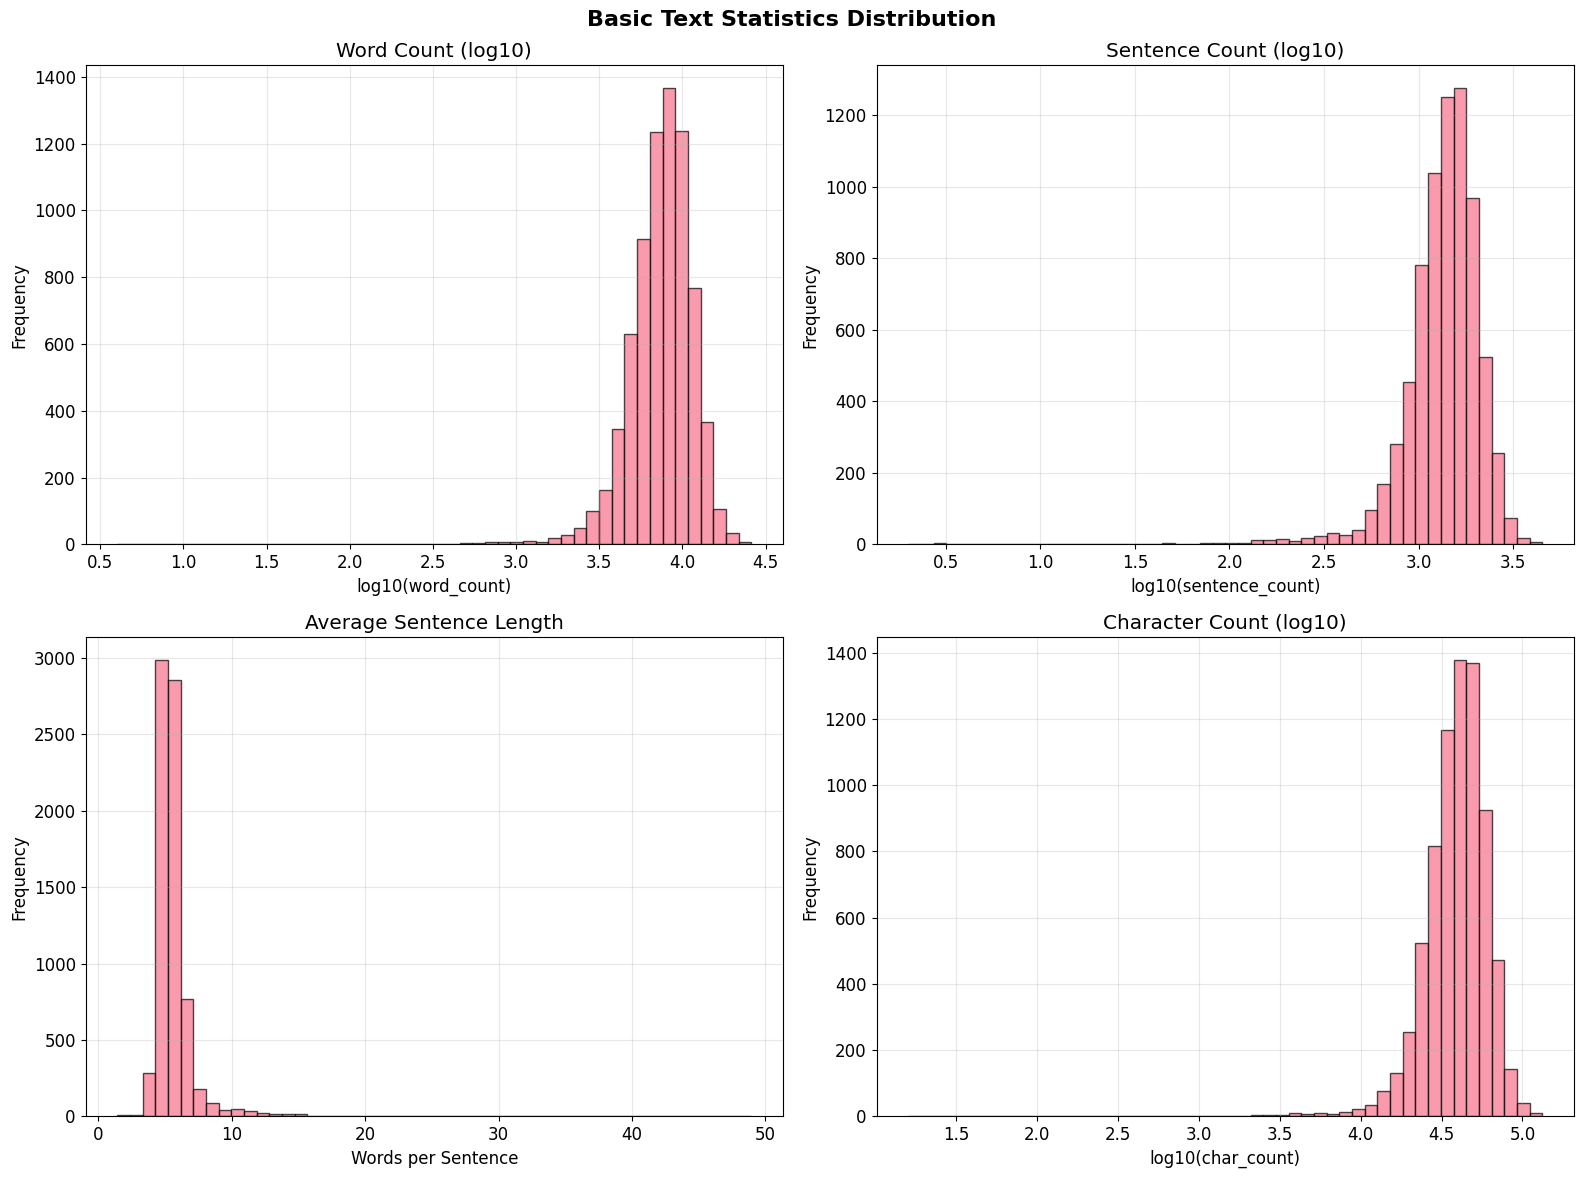


Basic text statistics summary:
       word_count  sentence_count  avg_sentence_length  char_count
count     7423.00         7423.00              7423.00     7423.00
mean      8049.19         1461.46                 7.96    42227.59
std       3073.54          546.91                90.76    16148.86
min          3.00            1.00                 1.41       15.00
25%       5887.50         1098.00                 4.88    30967.50
50%       7770.00         1433.00                 5.32    40705.00
75%       9904.00         1786.00                 5.89    51903.50
max      25929.00         4515.00              4697.00   132584.00


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Basic Text Statistics Distribution', fontsize=16, fontweight='bold')

axes[0, 0].hist(np.log10(nlp_df['word_count'] + 1), bins=50, alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Word Count (log10)')
axes[0, 0].set_xlabel('log10(word_count)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(alpha=0.3)

axes[0, 1].hist(np.log10(nlp_df['sentence_count'] + 1), bins=50, alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Sentence Count (log10)')
axes[0, 1].set_xlabel('log10(sentence_count)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(alpha=0.3)

valid_avg = nlp_df.loc[nlp_df['avg_sentence_length'].between(0.1, 50), 'avg_sentence_length']
axes[1, 0].hist(valid_avg, bins=50, alpha=0.7, edgecolor='black')
axes[1, 0].set_title('Average Sentence Length')
axes[1, 0].set_xlabel('Words per Sentence')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].grid(alpha=0.3)

axes[1, 1].hist(np.log10(nlp_df['char_count'] + 1), bins=50, alpha=0.7, edgecolor='black')
axes[1, 1].set_title('Character Count (log10)')
axes[1, 1].set_xlabel('log10(char_count)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_nlp_features_01_nlp_basic_text_stats.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nBasic text statistics summary:")
print(nlp_df[['word_count', 'sentence_count', 'avg_sentence_length', 'char_count']].describe().round(2))

Word and sentence counts are approximately log-normal. Average sentence length centres around 5–8 words, typical for dialogue-heavy subtitle text.

## 5. Lexical Diversity

Vocabulary richness metrics: type-token ratio, hapax legomena ratio, and unique word count.

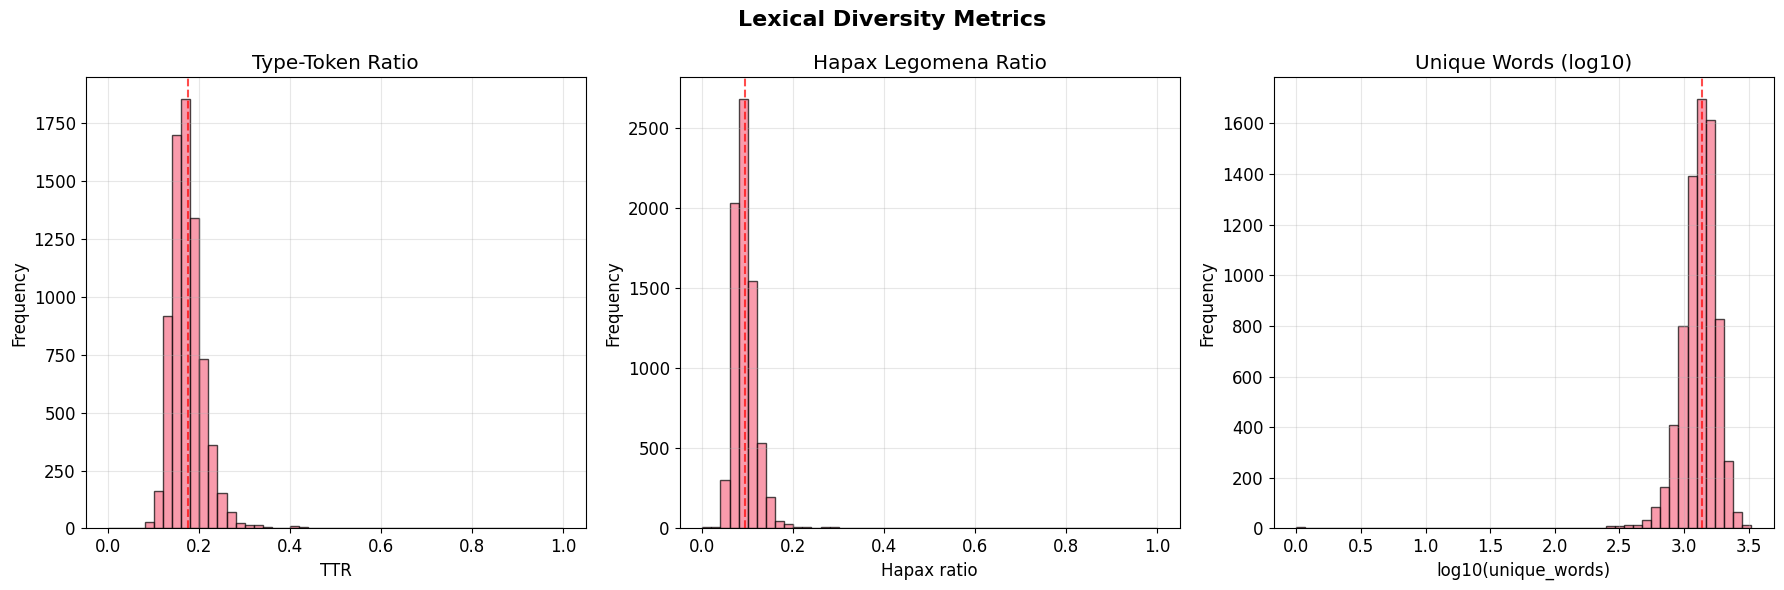


Lexical diversity summary:
       type_token_ratio  hapax_legomena_ratio  unique_words
count         7423.0000             7423.0000     7423.0000
mean             0.1743                0.0934     1366.8581
std              0.0415                0.0319      384.5943
min              0.0000                0.0000        0.0000
25%              0.1495                0.0761     1110.0000
50%              0.1689                0.0895     1349.0000
75%              0.1925                0.1053     1605.0000
max              1.0000                1.0000     3312.0000


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Lexical Diversity Metrics', fontsize=16, fontweight='bold')

axes[0].hist(nlp_df['type_token_ratio'], bins=50, alpha=0.7, edgecolor='black')
axes[0].axvline(nlp_df['type_token_ratio'].mean(), color='red', linestyle='--', alpha=0.7)
axes[0].set_title('Type-Token Ratio')
axes[0].set_xlabel('TTR')
axes[0].set_ylabel('Frequency')
axes[0].grid(alpha=0.3)

axes[1].hist(nlp_df['hapax_legomena_ratio'], bins=50, alpha=0.7, edgecolor='black')
axes[1].axvline(nlp_df['hapax_legomena_ratio'].mean(), color='red', linestyle='--', alpha=0.7)
axes[1].set_title('Hapax Legomena Ratio')
axes[1].set_xlabel('Hapax ratio')
axes[1].set_ylabel('Frequency')
axes[1].grid(alpha=0.3)

axes[2].hist(np.log10(nlp_df['unique_words'] + 1), bins=50, alpha=0.7, edgecolor='black')
axes[2].axvline(np.log10(nlp_df['unique_words'].mean()), color='red', linestyle='--', alpha=0.7)
axes[2].set_title('Unique Words (log10)')
axes[2].set_xlabel('log10(unique_words)')
axes[2].set_ylabel('Frequency')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_nlp_features_02_nlp_lexical_diversity.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nLexical diversity summary:")
print(nlp_df[['type_token_ratio', 'hapax_legomena_ratio', 'unique_words']].describe().round(4))

TTR averages ~0.17 — low because subtitles are long and conversational. Hapax ratio ~0.09 shows that about 9% of words appear only once. Films with richer vocabulary may correlate with genre or script quality.

## 6. Sentiment Analysis

VADER compound/positive/negative/neutral scores, polarity distribution, and box plots by commercial success.

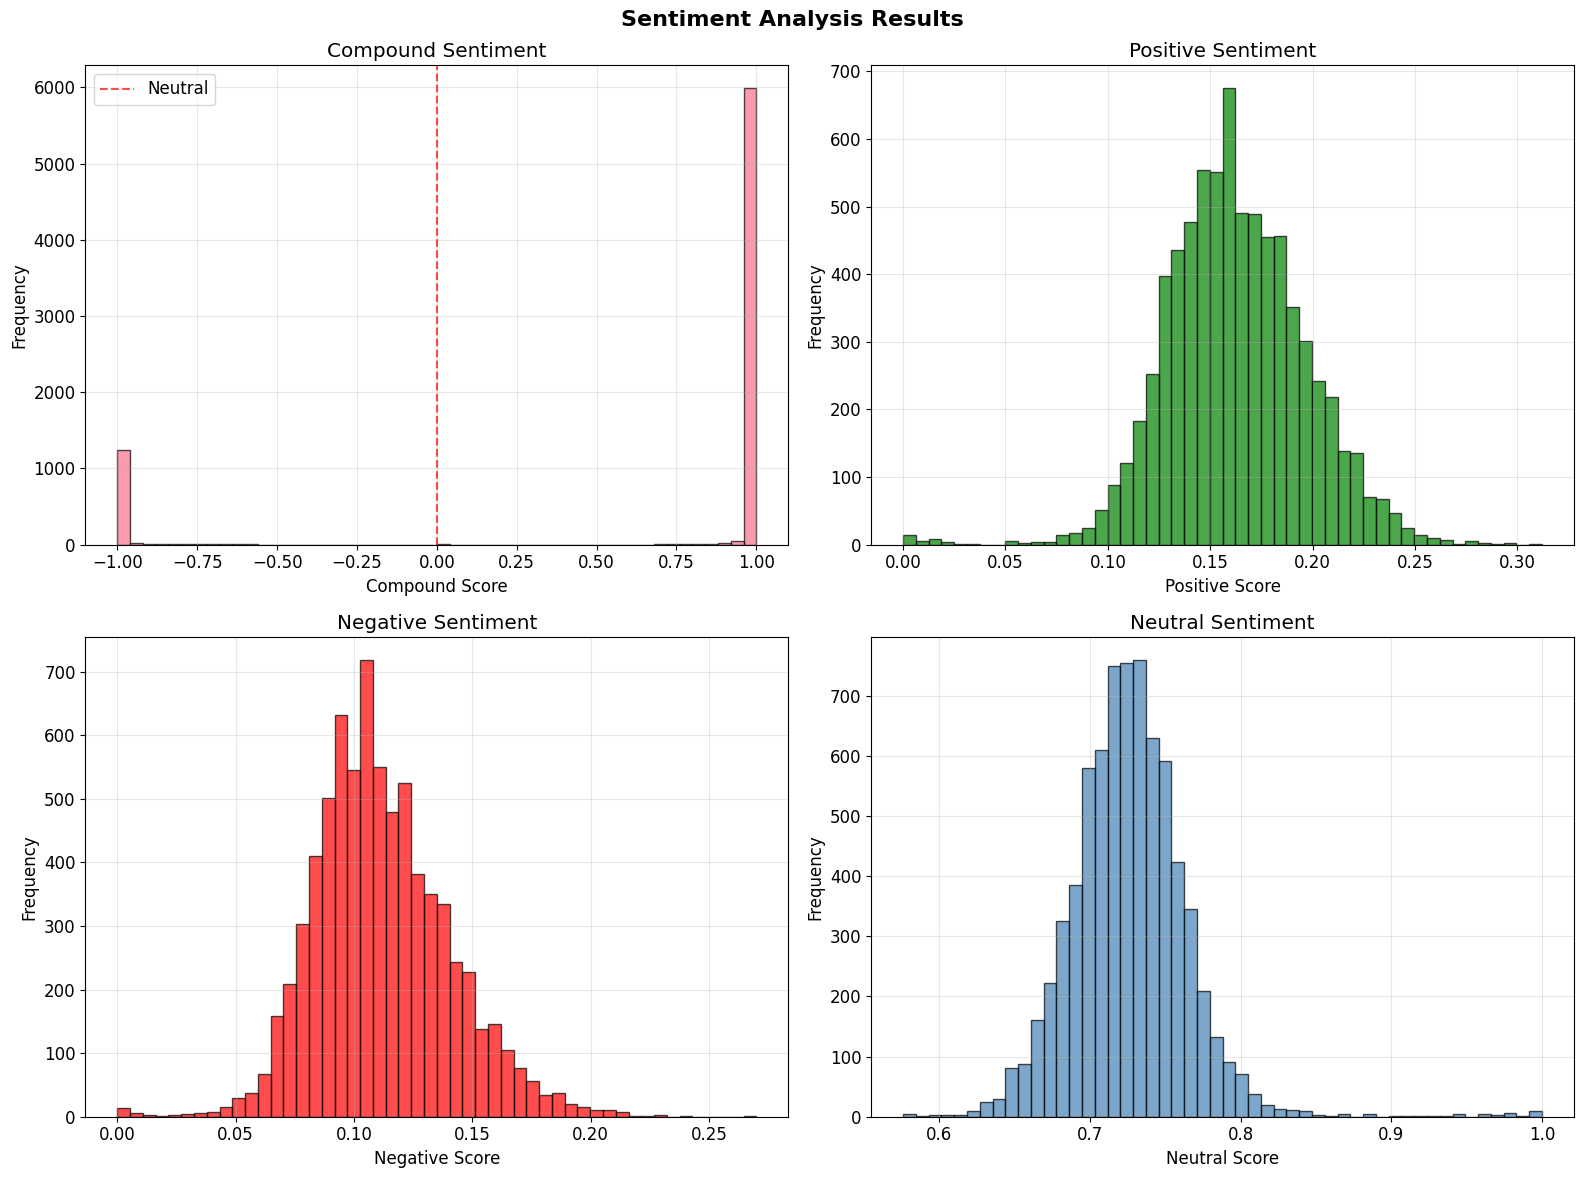

Sentiment polarity distribution:
  Positive (> 0.05):  6,082 (81.9%)
  Negative (< -0.05): 1,334 (18.0%)
  Neutral:            7 (0.1%)


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Sentiment Analysis Results', fontsize=16, fontweight='bold')

axes[0, 0].hist(nlp_df['sentiment_compound'], bins=50, alpha=0.7, edgecolor='black')
axes[0, 0].axvline(0, color='red', linestyle='--', alpha=0.7, label='Neutral')
axes[0, 0].set_title('Compound Sentiment')
axes[0, 0].set_xlabel('Compound Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].hist(nlp_df['sentiment_pos'], bins=50, alpha=0.7, edgecolor='black', color='green')
axes[0, 1].set_title('Positive Sentiment')
axes[0, 1].set_xlabel('Positive Score')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(alpha=0.3)

axes[1, 0].hist(nlp_df['sentiment_neg'], bins=50, alpha=0.7, edgecolor='black', color='red')
axes[1, 0].set_title('Negative Sentiment')
axes[1, 0].set_xlabel('Negative Score')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].grid(alpha=0.3)

axes[1, 1].hist(nlp_df['sentiment_neu'], bins=50, alpha=0.7, edgecolor='black', color='steelblue')
axes[1, 1].set_title('Neutral Sentiment')
axes[1, 1].set_xlabel('Neutral Score')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_nlp_features_03_nlp_sentiment_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

compound = nlp_df['sentiment_compound']
pos_n = (compound > 0.05).sum()
neg_n = (compound < -0.05).sum()
neu_n = len(compound) - pos_n - neg_n
print(f"Sentiment polarity distribution:")
print(f"  Positive (> 0.05):  {pos_n:,} ({pos_n/len(compound)*100:.1f}%)")
print(f"  Negative (< -0.05): {neg_n:,} ({neg_n/len(compound)*100:.1f}%)")
print(f"  Neutral:            {neu_n:,} ({neu_n/len(compound)*100:.1f}%)")

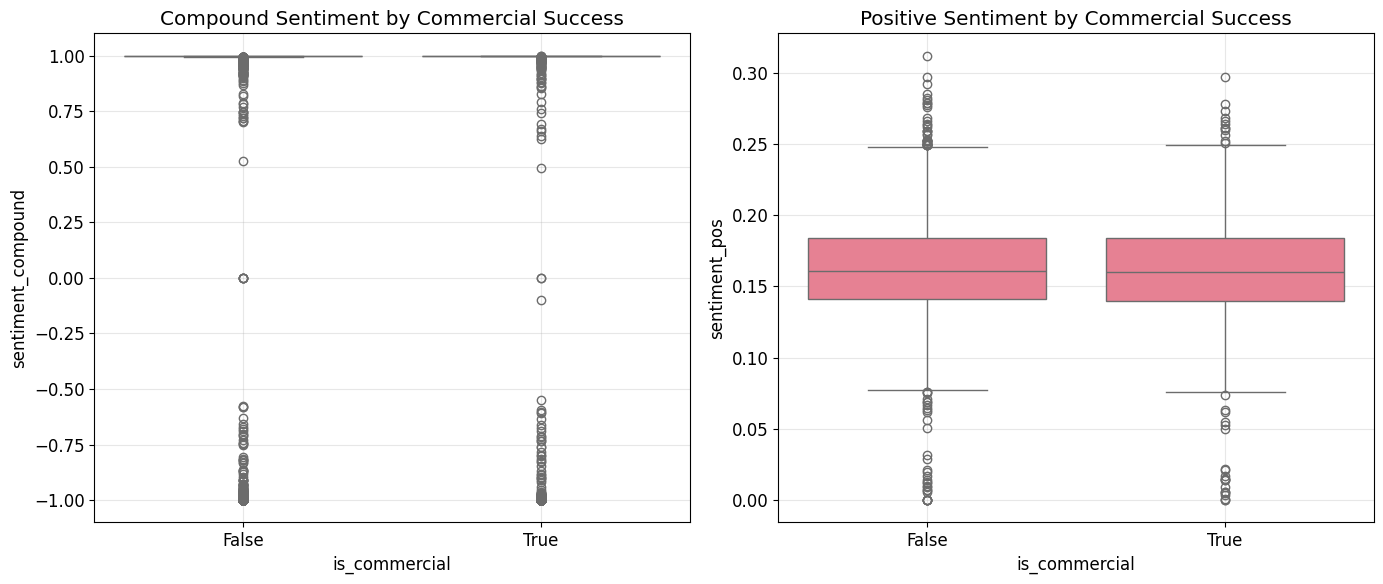

In [8]:
merged_sent = nlp_df[['id', 'sentiment_compound', 'sentiment_pos']].merge(
    df[['id', 'is_commercial']], on='id', how='inner'
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.boxplot(data=merged_sent, x='is_commercial', y='sentiment_compound', ax=axes[0])
axes[0].set_title('Compound Sentiment by Commercial Success')
axes[0].grid(alpha=0.3)

sns.boxplot(data=merged_sent, x='is_commercial', y='sentiment_pos', ax=axes[1])
axes[1].set_title('Positive Sentiment by Commercial Success')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_nlp_features_04_nlp_sentiment_by_success.png', dpi=150, bbox_inches='tight')
plt.show()

Most movies have positive compound sentiment at the full-text level, as dialogue naturally contains more positive expressions. Per-sentence variance and punctuation features may be more discriminative.

## 7. Correlation with Targets

Point-biserial correlation heatmap showing how each NLP feature relates to `is_commercial` and `is_award_winner`. Only movies with valid budget, revenue, and runtime are included.

Merged subset for correlation: 5,754 movies


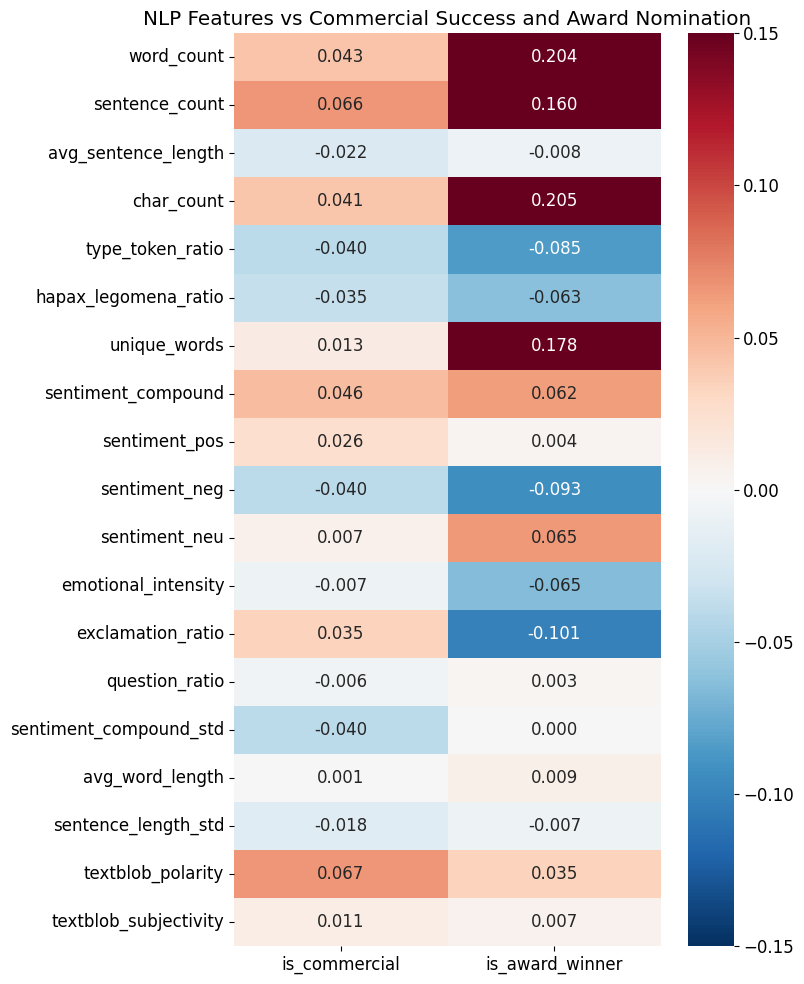

Text features show non-zero correlations with both targets, justifying the use of NLP in the models.


In [9]:
main = pd.read_csv(PROCESSED_DIR / 'final_movie_list.csv')
valid = (main['budget'] > 0) & (main['revenue'] > 0) & (main['runtime'] > 0)
merge_df = nlp_df.merge(main.loc[valid, ['id', 'is_commercial', 'is_award_winner']], on='id', how='inner')
print(f"Merged subset for correlation: {len(merge_df):,} movies")

nlp_numeric = [
    'word_count', 'sentence_count', 'avg_sentence_length', 'char_count',
    'type_token_ratio', 'hapax_legomena_ratio', 'unique_words',
    'sentiment_compound', 'sentiment_pos', 'sentiment_neg', 'sentiment_neu',
    'emotional_intensity', 'exclamation_ratio', 'question_ratio',
    'sentiment_compound_std', 'avg_word_length', 'sentence_length_std',
    'textblob_polarity', 'textblob_subjectivity',
]
nlp_numeric = [c for c in nlp_numeric if c in merge_df.columns]

def point_biserial_r(x, y):
    m1, m0 = x[y == 1].mean(), x[y == 0].mean()
    p = y.mean()
    sigma = x.std()
    if sigma == 0:
        return 0.0
    return (m1 - m0) * np.sqrt(p * (1 - p)) / sigma

corr_comm = {c: point_biserial_r(merge_df[c].astype(float), merge_df['is_commercial'].astype(int)) for c in nlp_numeric}
corr_award = {c: point_biserial_r(merge_df[c].astype(float), merge_df['is_award_winner'].astype(int)) for c in nlp_numeric}
corr_df = pd.DataFrame({'is_commercial': corr_comm, 'is_award_winner': corr_award})

fig, ax = plt.subplots(figsize=(8, 10))
sns.heatmap(corr_df, annot=True, fmt='.3f', cmap='RdBu_r', center=0, ax=ax, vmin=-0.15, vmax=0.15)
ax.set_title('NLP Features vs Commercial Success and Award Nomination')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_nlp_features_05_nlp_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Text features show non-zero correlations with both targets, justifying the use of NLP in the models.")

Several NLP features have statistically meaningful (if modest) correlations with both success targets. Sentiment, lexical diversity, and readability metrics all carry signal.

## 8. TF-IDF Vectorization

Build a TF-IDF matrix from cleaned subtitle text (5,000 terms, min_df=5, max_df=0.8, unigrams + bigrams). Only documents with ≥10 words are included.

In [10]:
print("Building TF-IDF corpus from subtitle files...")
corpus = []
corpus_ids = []

for mid in sorted(nlp_df['id'].tolist()):
    fp = SUBTITLES_DIR / f"{mid}.txt"
    if not fp.exists():
        continue
    with open(fp, 'r', encoding='utf-8', errors='ignore') as f:
        raw = f.read()
    cleaned = clean_subtitle_text(raw)
    if len(cleaned.split()) >= 10:
        corpus.append(cleaned)
        corpus_ids.append(mid)

print(f"Corpus: {len(corpus):,} documents (filtered from {len(nlp_df):,})")
print(f"Average document length: {np.mean([len(d.split()) for d in corpus]):.0f} words")

tfidf_vec, tfidf_matrix = create_tfidf_vectorizer(corpus, max_features=5000)

top_terms = get_top_tfidf_terms(tfidf_vec, tfidf_matrix, top_n=20)
print("\nTop 20 TF-IDF terms:")
for term, score in top_terms:
    print(f"  {term}: {score:.4f}")

Building TF-IDF corpus from subtitle files...
Corpus: 7,422 documents (filtered from 7,423)
Average document length: 8050 words
TF-IDF: 7,422 docs x 5,000 terms, sparsity 82.0%

Top 20 TF-IDF terms:
  okay: 0.0990
  uh: 0.0454
  fuck: 0.0415
  fucking: 0.0385
  ok: 0.0371
  mr: 0.0370
  shit: 0.0362
  sir: 0.0341
  guys: 0.0260
  wanna: 0.0258
  dad: 0.0248
  guy: 0.0241
  hi: 0.0230
  money: 0.0227
  father: 0.0224
  gotta: 0.0224
  huh: 0.0222
  mom: 0.0216
  ain: 0.0215
  baby: 0.0213


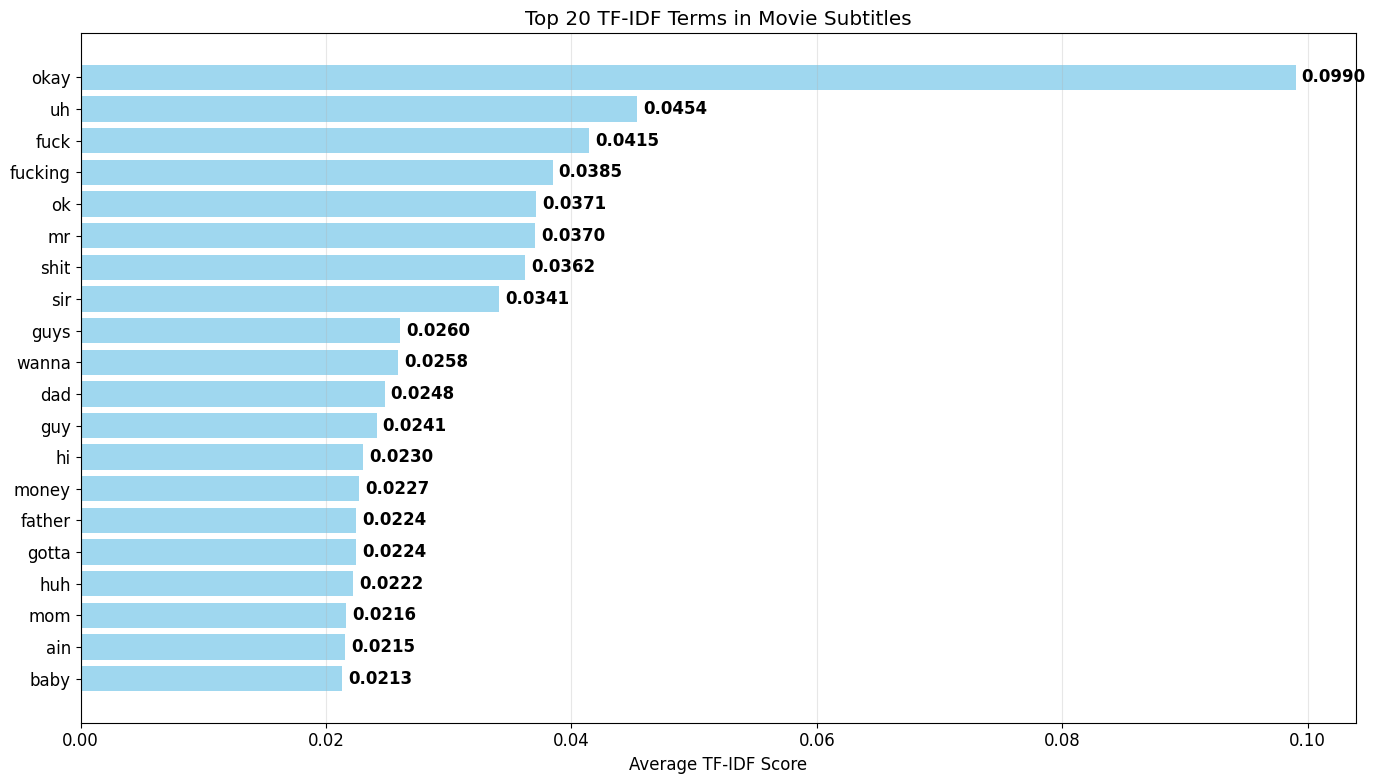

Matrix shape: (7422, 5000)
Sparsity: 82.0%
Non-zero elements: 6,676,847
Avg non-zero per document: 899.6


In [11]:
terms_20 = [t for t, s in top_terms]
scores_20 = [s for t, s in top_terms]

plt.figure(figsize=(14, 8))
bars = plt.barh(range(len(terms_20)), scores_20, color='skyblue', alpha=0.8)
plt.yticks(range(len(terms_20)), terms_20)
plt.xlabel('Average TF-IDF Score')
plt.title('Top 20 TF-IDF Terms in Movie Subtitles')
plt.grid(axis='x', alpha=0.3)
for i, (bar, score) in enumerate(zip(bars, scores_20)):
    plt.text(score + 0.0005, i, f'{score:.4f}', va='center', fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_nlp_features_06_nlp_tfidf_top_terms.png', dpi=150, bbox_inches='tight')
plt.show()

sparsity = 1.0 - (tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]))
print(f"Matrix shape: {tfidf_matrix.shape}")
print(f"Sparsity: {sparsity:.1%}")
print(f"Non-zero elements: {tfidf_matrix.nnz:,}")
print(f"Avg non-zero per document: {tfidf_matrix.nnz / tfidf_matrix.shape[0]:.1f}")

Top terms reflect conversational dialogue patterns (e.g. "okay", "uh", profanity) rather than content-specific vocabulary — TF-IDF is capturing stylistic register and tone.

## 9. Save Features

Persist the NLP feature table, TF-IDF matrix, vocabulary, and corpus-ID mapping.

In [12]:
final_cols = [
    'id', 'word_count', 'sentence_count', 'avg_sentence_length', 'char_count',
    'type_token_ratio', 'hapax_legomena_ratio', 'unique_words',
    'sentiment_compound', 'sentiment_pos', 'sentiment_neg', 'sentiment_neu',
    'emotional_intensity', 'exclamation_ratio', 'question_ratio',
    'sentiment_compound_std', 'avg_word_length', 'sentence_length_std',
    'textblob_polarity', 'textblob_subjectivity',
]
available = [c for c in final_cols if c in nlp_df.columns]
final_nlp_df = nlp_df[available].copy()
numeric = [c for c in available if c != 'id']
final_nlp_df[numeric] = final_nlp_df[numeric].astype(float)

nlp_path = PROCESSED_DIR / 'nlp_features.csv'
final_nlp_df.to_csv(nlp_path, index=False)
print(f"Saved {nlp_path.name}: {final_nlp_df.shape}")

tfidf_path = PROCESSED_DIR / 'tfidf_matrix.npz'
scipy.sparse.save_npz(tfidf_path, tfidf_matrix)
print(f"Saved {tfidf_path.name}")

vocab_path = PROCESSED_DIR / 'tfidf_vocab.pkl'
tfidf_vocab = {t: i for i, t in enumerate(tfidf_vec.get_feature_names_out())}
with open(vocab_path, 'wb') as f:
    pickle.dump(tfidf_vocab, f)
print(f"Saved {vocab_path.name}")

ids_path = PROCESSED_DIR / 'tfidf_corpus_ids.pkl'
with open(ids_path, 'wb') as f:
    pickle.dump(corpus_ids, f)
print(f"Saved {ids_path.name}")

print("\nFile sizes:")
for p in [nlp_path, tfidf_path, vocab_path, ids_path]:
    print(f"  {p.name}: {p.stat().st_size / (1024 * 1024):.2f} MB")

Saved nlp_features.csv: (7423, 20)
Saved tfidf_matrix.npz
Saved tfidf_vocab.pkl
Saved tfidf_corpus_ids.pkl

File sizes:
  nlp_features.csv: 1.83 MB
  tfidf_matrix.npz: 55.66 MB
  tfidf_vocab.pkl: 0.06 MB
  tfidf_corpus_ids.pkl: 0.03 MB


## 10. Summary

### NLP Feature Extraction Results

**Coverage:** ~7,400 movies (58% of the dataset) have subtitle files and were successfully processed.

**Features extracted per movie (19 numeric features + `id`):**

| Group | Features |
|-------|----------|
| Basic stats | word_count, sentence_count, avg_sentence_length, char_count |
| Lexical diversity | type_token_ratio, hapax_legomena_ratio, unique_words |
| VADER sentiment | sentiment_compound, sentiment_pos, sentiment_neg, sentiment_neu |
| Punctuation / energy | emotional_intensity, exclamation_ratio, question_ratio |
| Sentiment variance | sentiment_compound_std |
| Readability | avg_word_length, sentence_length_std |
| TextBlob | textblob_polarity, textblob_subjectivity |

**TF-IDF:** 5,000-term sparse matrix (unigrams + bigrams, ~82% sparsity).

**Correlation analysis** confirms that text features carry signal for both commercial success and award nomination — justifying their inclusion in the modeling pipeline.

### Output files
- `nlp_features.csv` — numeric NLP features for all subtitled movies
- `tfidf_matrix.npz` — sparse TF-IDF matrix
- `tfidf_vocab.pkl` — term-to-index vocabulary
- `tfidf_corpus_ids.pkl` — movie ID to TF-IDF row mapping

All NLP features are now ready for the modeling phase (notebook 03).